#Customer Intelligence System using Classification, Ensemble Learning & Clustering




In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Dataset

df = pd.read_csv("Country-data.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
# Shape of dataset

print("Shape of Dataset:", df.shape)

Shape of Dataset: (167, 10)


In [5]:
# Display column names

print(df.columns)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [6]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
# Statistical Summary

df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# Data Cleaning and Exploratory Data Analysis (EDA)



In [8]:
# Check for missing values

df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [9]:
# Check duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
# Check data types

df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


## Correlation Analysis



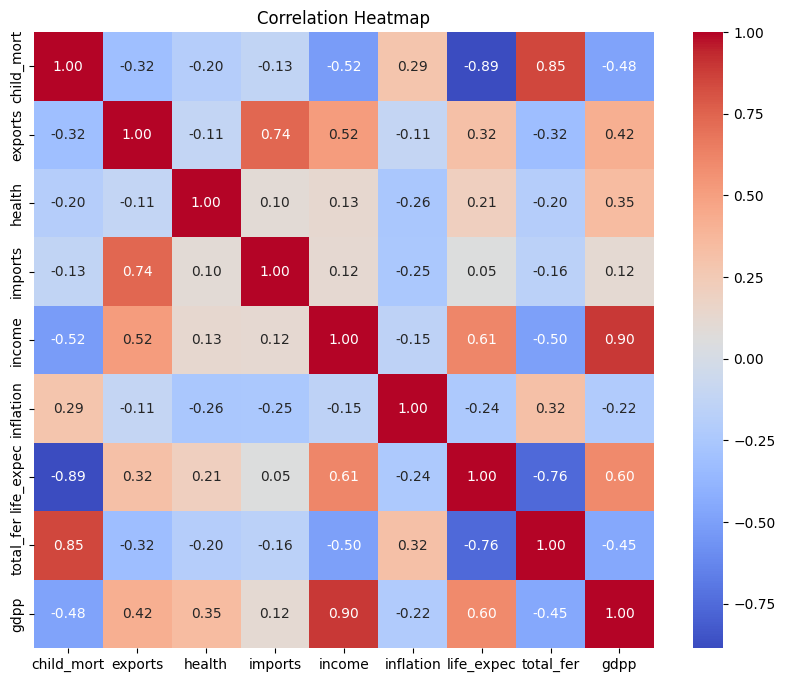

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(df.drop("country", axis=1).corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

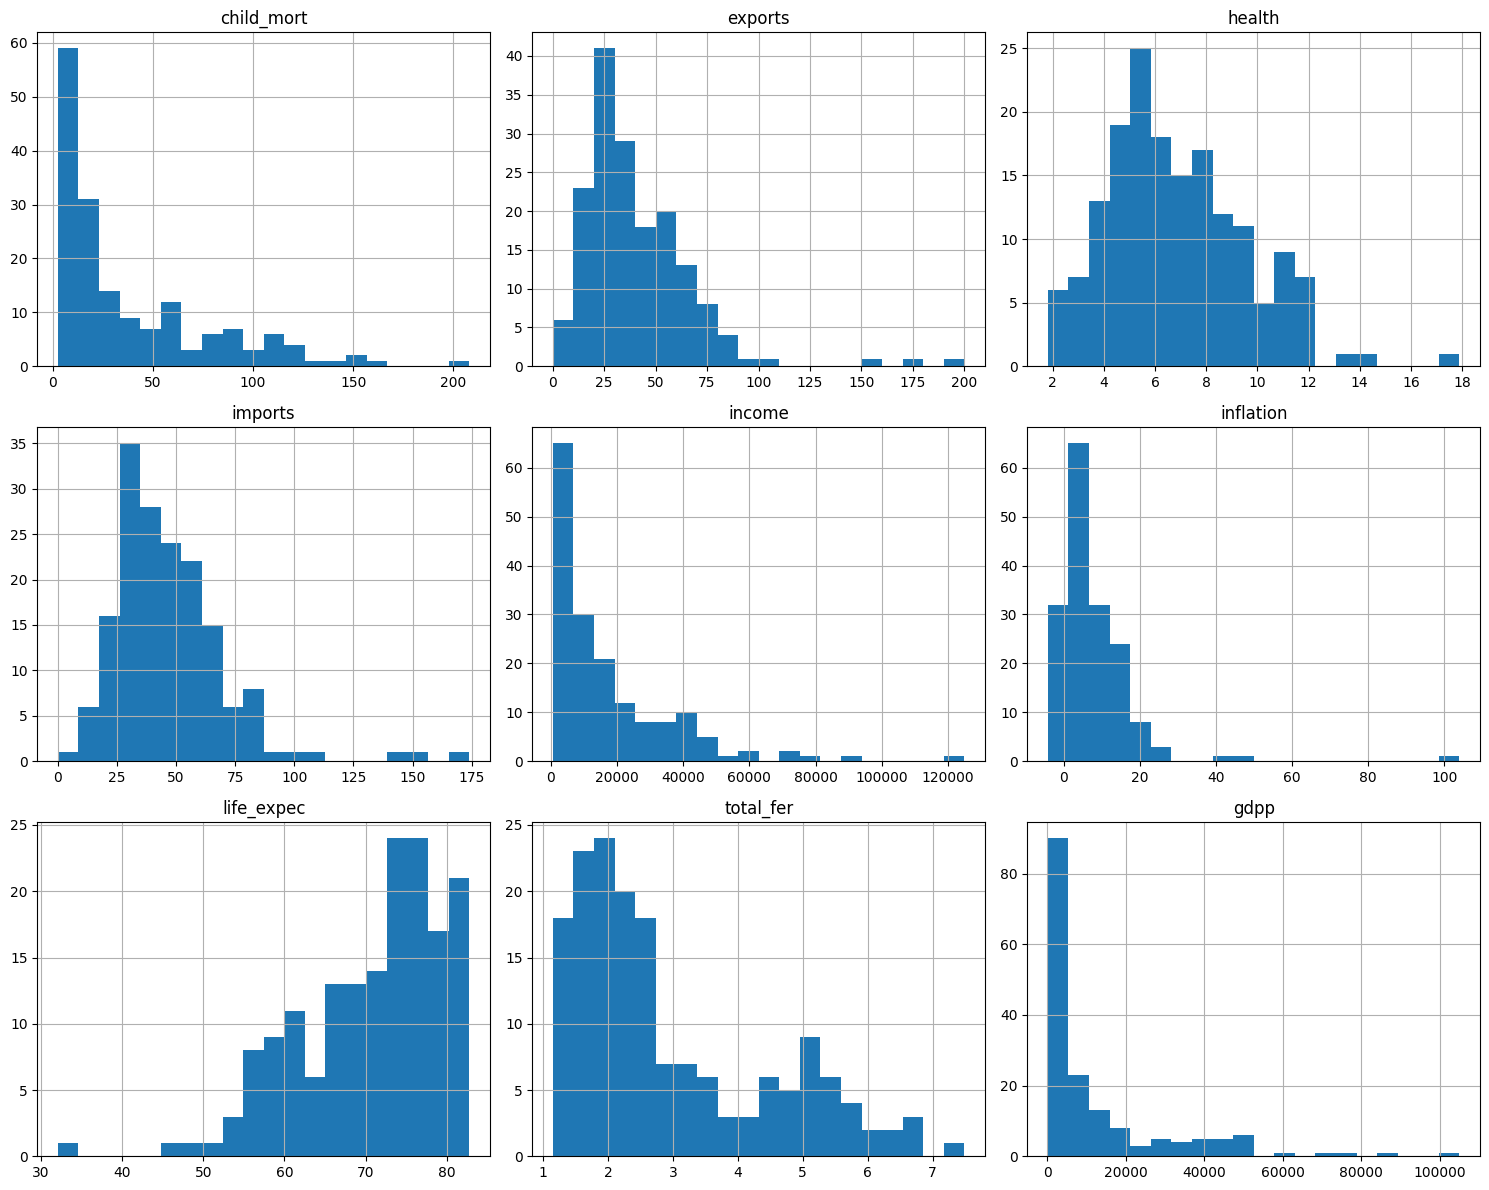

In [12]:
# Distribution of all numerical features

df.drop("country", axis=1).hist(figsize=(15,12), bins=20)

plt.tight_layout()

plt.show()

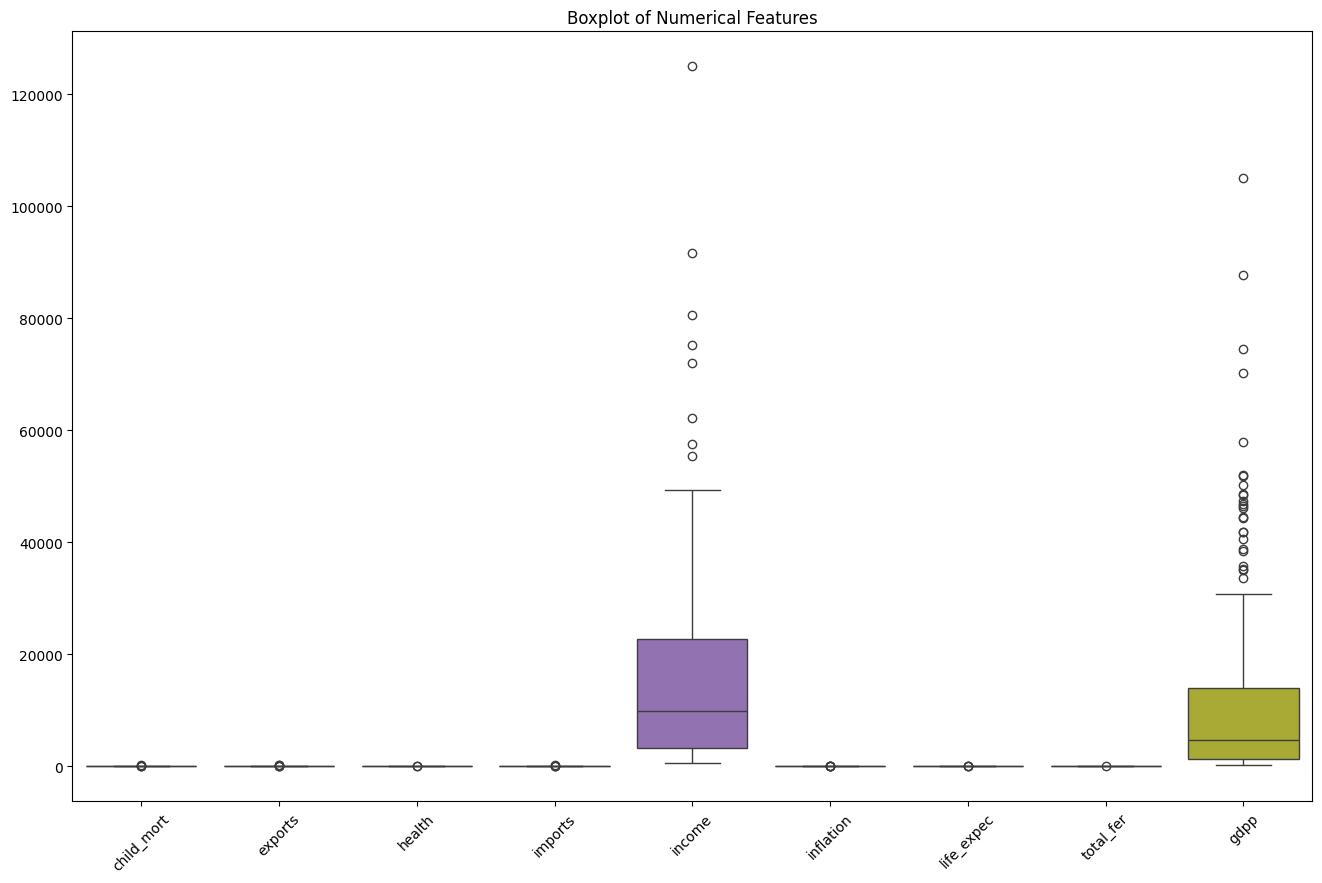

In [13]:
plt.figure(figsize=(16,10))

sns.boxplot(data=df.drop("country", axis=1))

plt.xticks(rotation=45)

plt.title("Boxplot of Numerical Features")

plt.show()

### EDA Observations

- The dataset contains 167 countries and 10 features.
- No missing values or duplicate records were found.
- The correlation heatmap shows relationships between socio-economic and health indicators.
- Several numerical features contain outliers, which are expected because countries differ significantly in income, GDP, life expectancy, and child mortality.
- Since distance-based algorithms are sensitive to feature scales, feature scaling will be performed before clustering.

# Feature Scaling

Machine Learning algorithms such as K-Means and DBSCAN use distance calculations. Therefore, all numerical features are standardized so that every feature contributes equally during clustering.

In [14]:
# Store country names separately

country_names = df["country"]

# Keep only numerical columns

X = df.drop("country", axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [15]:
# Standardize the data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [17]:
print("Shape of Scaled Data:", X_scaled.shape)

Shape of Scaled Data: (167, 9)


# K-Means Clustering

K-Means is an unsupervised machine learning algorithm that groups similar data points into clusters based on their feature values. The objective is to identify countries with similar socio-economic characteristics.

In [18]:
# Finding the optimal number of clusters using the Elbow Method

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

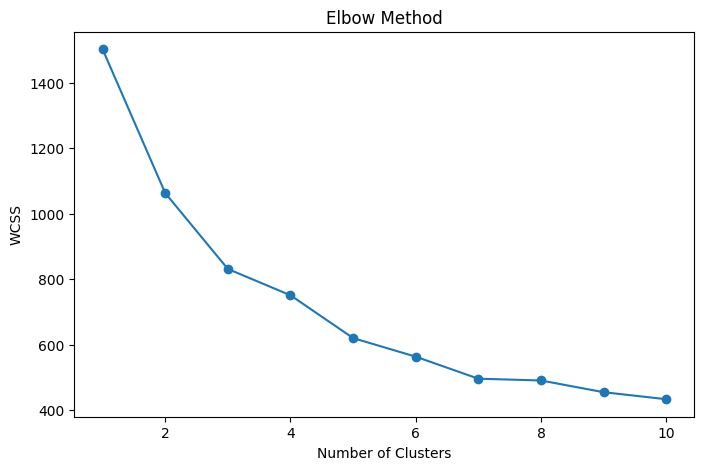

In [19]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

### Selecting the Optimal Number of Clusters

The Elbow Method was used to determine the optimal number of clusters. Based on the graph, the curve begins to flatten after **K = 3**, indicating that three clusters provide a good balance between compactness and simplicity. Therefore, **K = 3** was selected for K-Means clustering.

In [20]:
# Apply K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

In [21]:
# Add cluster labels to the dataset

df["KMeans_Cluster"] = kmeans_labels

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [22]:
df["KMeans_Cluster"].value_counts()

,count
KMeans_Cluster,
0,86
2,45
1,36


In [23]:
score = silhouette_score(X_scaled, kmeans_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.285600988953231


### K-Means Clustering Results

- The Elbow Method suggested that **3 clusters** provide a suitable balance between model complexity and cluster compactness.
- K-Means successfully divided the countries into three groups.
- The Silhouette Score obtained was **0.286**, indicating a reasonable level of cluster separation for this dataset.
- The resulting clusters can be further analyzed to understand similarities and differences among countries based on socio-economic indicators.

# Cluster Visualization using PCA

Principal Component Analysis (PCA) is used to reduce the dimensionality of the dataset from 9 features to 2 principal components for visualization purposes.

In [24]:
from sklearn.decomposition import PCA

# Reduce dimensions to 2

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

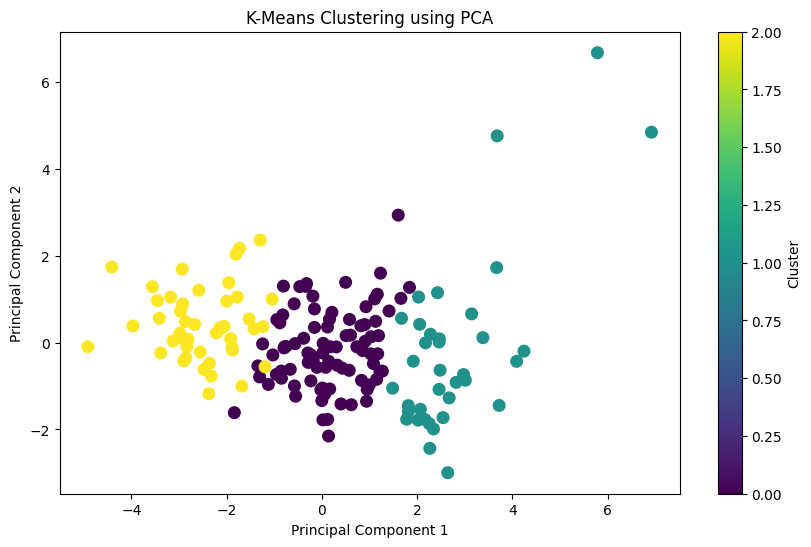

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="viridis",
    s=70
)

plt.title("K-Means Clustering using PCA")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

# DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm. Unlike K-Means, it does not require specifying the number of clusters beforehand and can identify outliers as noise.

In [26]:
# Apply DBSCAN

dbscan = DBSCAN(eps=1.2, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

In [27]:
# Add DBSCAN cluster labels

df["DBSCAN_Cluster"] = dbscan_labels

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,1


In [28]:
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 1    75
-1    53
 0    21
 2    18
Name: count, dtype: int64


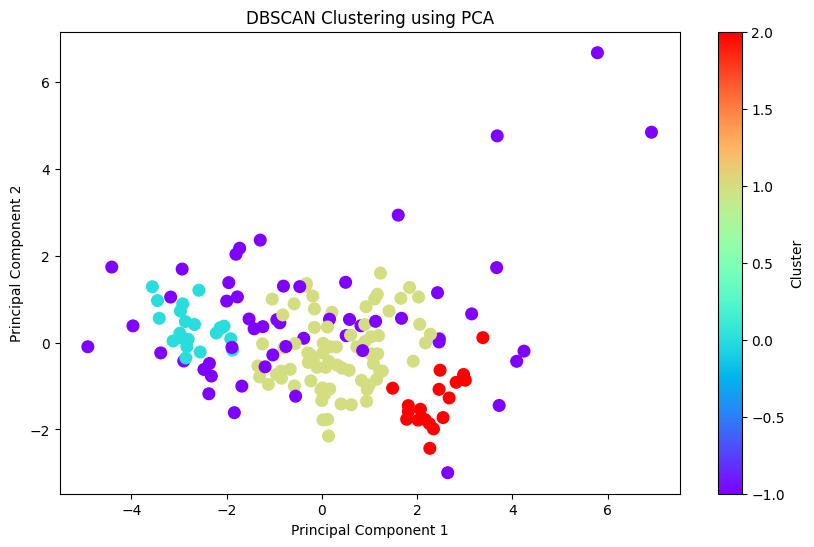

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    cmap="rainbow",
    s=70
)

plt.title("DBSCAN Clustering using PCA")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [30]:
num_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print("Number of clusters:", num_clusters)

Number of clusters: 3


### DBSCAN Results

- DBSCAN automatically identified clusters based on the density of data points.
- Some countries may be labeled as **-1**, which represents noise or outliers.
- Unlike K-Means, DBSCAN does not require specifying the number of clusters beforehand.
- This makes DBSCAN suitable for datasets with irregular cluster shapes and potential outliers.

# Classification using Ensemble Learning

Since the original dataset does not contain predefined class labels, the clusters generated by K-Means are used as target labels. Ensemble learning models (Random Forest and XGBoost) are then trained to predict these cluster assignments.

In [31]:
# Features

X = df.drop(["country", "KMeans_Cluster", "DBSCAN_Cluster"], axis=1)

# Target

y = df["KMeans_Cluster"]

print(X.shape)
print(y.shape)

(167, 9)
(167,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(133, 9)
(34, 9)


In [33]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [34]:
rf_pred = rf.predict(X_test)

In [35]:
print("Random Forest Accuracy:")

print(accuracy_score(y_test, rf_pred))

Random Forest Accuracy:
0.9705882352941176


In [36]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



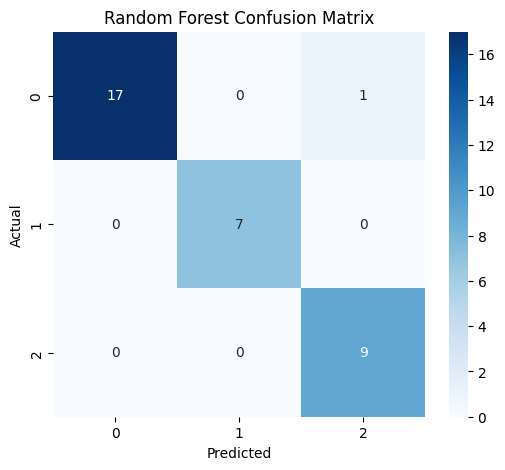

In [37]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

# XGBoost Classification



In [38]:
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [39]:
xgb_pred = xgb.predict(X_test)

In [40]:
print("XGBoost Accuracy:")
print(accuracy_score(y_test, xgb_pred))

XGBoost Accuracy:
0.9705882352941176


In [41]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



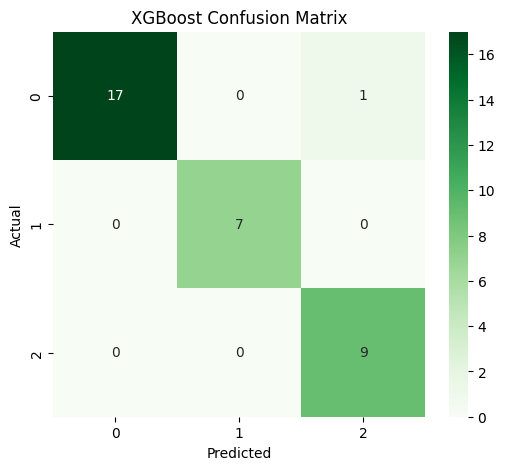

In [42]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm_xgb,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Comparison

The performance of Random Forest and XGBoost is compared using classification accuracy.

In [43]:
rf_accuracy = accuracy_score(y_test, rf_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy]
})

comparison

,Model,Accuracy
0,Random Forest,0.970588
1,XGBoost,0.970588


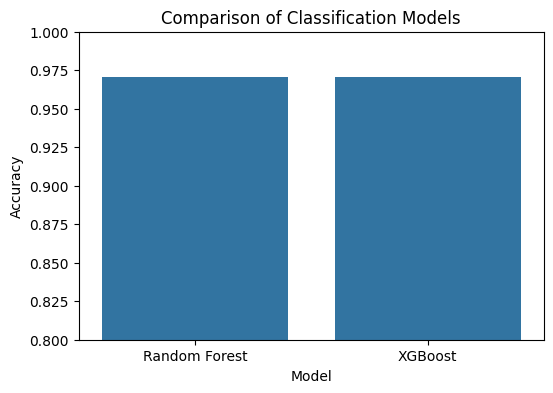

In [44]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(0.8,1.0)

plt.title("Comparison of Classification Models")

plt.show()

# Feature Importance

Random Forest provides feature importance scores that indicate which features contributed the most to the classification process.

In [45]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.296120
8,gdpp,0.227301
4,income,0.164629
6,life_expec,0.164469
7,total_fer,0.097647
2,health,0.017380
1,exports,0.011820
5,inflation,0.011761
3,imports,0.008873


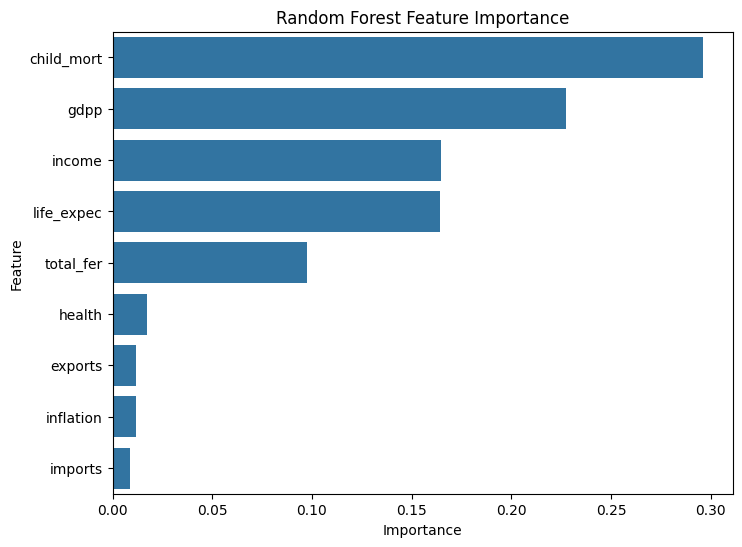

In [46]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

# Business Insights

- Countries were successfully grouped into distinct clusters based on socio-economic and health indicators.
- K-Means identified three meaningful clusters representing different development levels.
- DBSCAN additionally identified several countries as outliers, indicating unique socio-economic conditions.
- Random Forest and XGBoost achieved high classification accuracy when predicting the generated cluster labels.
- Features with higher importance contribute more significantly in distinguishing country groups.

# Conclusion

This project successfully applied clustering and ensemble learning techniques to analyze country-level socio-economic data.

K-Means and DBSCAN were used to identify patterns and group similar countries, while Random Forest and XGBoost were used to classify the generated clusters.

The results demonstrate how machine learning techniques can support intelligent data-driven segmentation and provide meaningful insights for decision-making.

This project demonstrates how clustering and ensemble learning techniques can be combined to extract meaningful patterns from structured data and support intelligent decision-making.